# 🛍️ Customer Segmentation using K-Means Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans


In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 🔍 Data Exploration
## We visualize relationships between features to understand patterns.

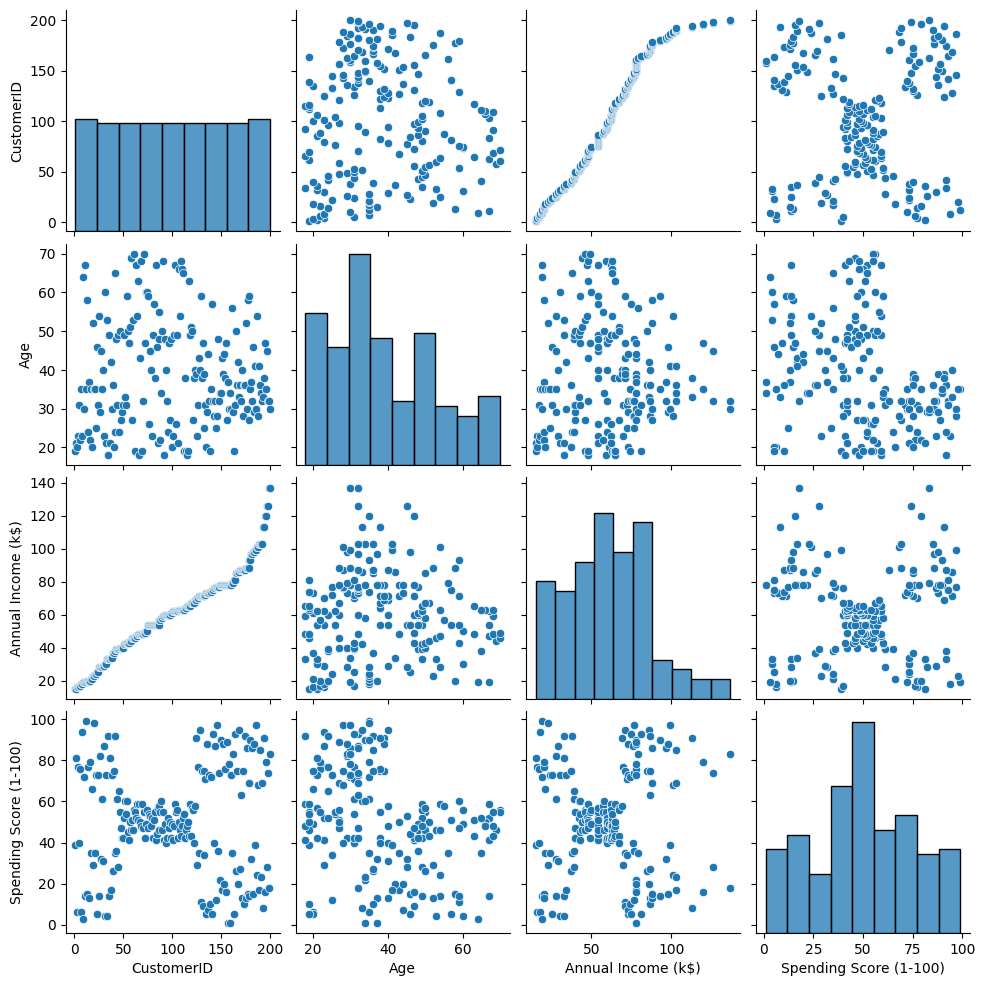

In [3]:
sns.pairplot(df)
plt.show()

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

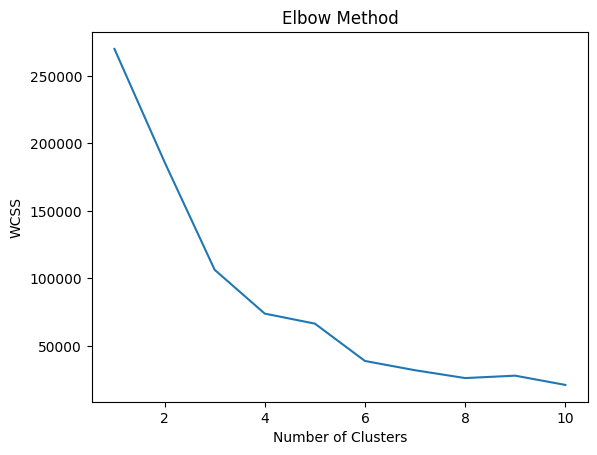

In [5]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=5)
y_kmeans = kmeans.fit_predict(X)

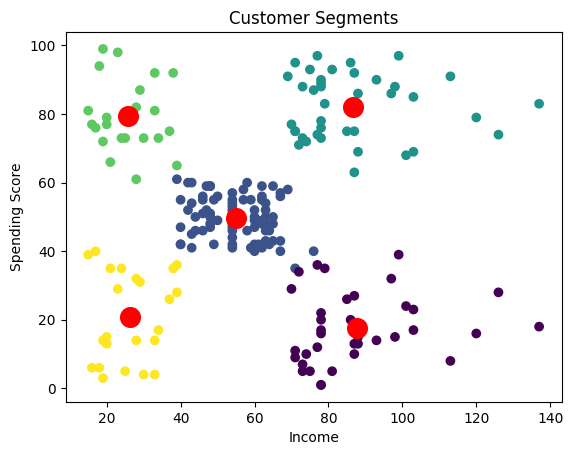

In [7]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, c='red')
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

## 🧠 Insights

- Customers are grouped into 5 segments.
- High income + high spending → target customers.
- Low income + low spending → low priority.
- Clustering helps businesses plan marketing strategies.

In [8]:
df['Cluster'] = y_kmeans

In [9]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,163.500000,40.666667,87.750000,17.583333
1,85.737500,42.937500,55.087500,49.712500
2,162.000000,32.692308,86.538462,82.128205
3,23.090909,25.272727,25.727273,79.363636
4,23.000000,45.217391,26.304348,20.913043


In [10]:
def label_cluster(cluster):
    if cluster == 0:
        return "High Income - High Spending (VIP)"
    elif cluster == 1:
        return "Low Income - Low Spending"
    elif cluster == 2:
        return "High Income - Low Spending (Saver)"
    elif cluster == 3:
        return "Low Income - High Spending"
    else:
        return "Average Customers"

df['Customer Type'] = df['Cluster'].apply(label_cluster)

In [11]:
df[['Annual Income (k$)', 'Spending Score (1-100)', 'Customer Type']].head()

,Annual Income (k$),Spending Score (1-100),Customer Type
0,15,39,Average Customers
1,15,81,Low Income - High Spending
2,16,6,Average Customers
3,16,77,Low Income - High Spending
4,17,40,Average Customers


In [12]:
new_customer = [[50, 60]]  # income, spending

cluster = kmeans.predict(new_customer)

print("Cluster:", cluster)

Cluster: [1]


C:\Users\abhin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [13]:
print("Customer Type:", label_cluster(cluster[0]))

Customer Type: Low Income - Low Spending


## 🧠 Business Insights

- VIP customers should be targeted with premium offers.
- Low income customers may respond better to discounts.
- High income but low spending customers can be encouraged through marketing strategies.

In [15]:
import joblib
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']